# Comparacion de LDA y QDA con dataset Wine

In [1]:
# Importacion de librerias necesarias para todo el notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from matplotlib.colors import ListedColormap
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

# Semilla fija para que los resultados sean reproducibles en todo el notebook
SEMILLA = 19
np.random.seed(SEMILLA)

# Configuracion visual general de los graficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

**1. Descripcion del conjunto de datos**

**Origen:** el dataset Wine proviene del repositorio UCI Machine Learning
Repository, contiene los resultados de un analisis quimico de vinos cultivados
en la region de Italia, pero derivados de tres cultivares (variedades de
uva) distintos. Se accede directamente desde scikit-learn mediante la funcion
`load_wine()`, sin limpieza

**Numero de observaciones:** 178 muestras de vino.

**Variables predictoras:** 13 variables numericas continuas obtenidas de un
analisis quimico (alcohol, acido malico, ceniza, alcalinidad de la ceniza,
magnesio, fenoles totales, flavonoides, fenoles no flavonoides,
proantocianinas, intensidad de color, tono, OD280/OD315 de vinos diluidos y
prolina).

**Variable objetivo:** la clase de cultivar (target), con valores 0, 1 o 2,
cada uno representando una variedad de uva distinta.

**Cantidad de clases:** 3 clases, con una distribucion moderadamente
desbalanceada entre ellas.

In [2]:
# Carga del dataset Wine directamente desde scikit-learn, sin tratamiento previo
datos_wine = load_wine()

# Se construye un DataFrame para facilitar el analisis exploratorio
df = pd.DataFrame(datos_wine.data, columns=datos_wine.feature_names)
df['target'] = datos_wine.target

# Se agrega tambien el nombre de la clase para lecturas mas claras en los graficos
nombres_clases = datos_wine.target_names
df['clase'] = df['target'].map(lambda i: nombres_clases[i])

print("Origen del dataset:", "UCI Machine Learning Repository (via sklearn.datasets.load_wine)")
print("Numero de observaciones:", df.shape[0])
print("Numero de variables predictoras:", len(datos_wine.feature_names))
print("Cantidad de clases:", len(nombres_clases))
print("Nombres de las clases:", list(nombres_clases))
df.head()

Origen del dataset: UCI Machine Learning Repository (via sklearn.datasets.load_wine)
Numero de observaciones: 178
Numero de variables predictoras: 13
Cantidad de clases: 3
Nombres de las clases: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,clase
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


**2. Exploracion de los datos**

In [3]:
# Dimensiones del conjunto de datos (filas, columnas)
print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (178, 15)


In [4]:
# Tipos de datos de cada variable
# Todas las variables predictoras son numericas de tipo float64,
# y la variable objetivo (target) es numerica de tipo int
df.dtypes

,0
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64


In [5]:
# Verificacion de valores faltantes por columna
# El dataset Wine de sklearn no contiene valores nulos, pero se verifica
# de todas formas ya que el dataset se usa sin ningun tratamiento previo
print("Valores faltantes por columna:")
print(df.isnull().sum())
print("\nTotal de valores faltantes en el dataset:", df.isnull().sum().sum())

Valores faltantes por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
clase                           0
dtype: int64

Total de valores faltantes en el dataset: 0


In [6]:
# Estadisticas descriptivas de las variables predictoras
# Permite observar la escala, el rango y la dispersion de cada variable
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


clase
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


/tmp/ipykernel_1380/2715687978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_clases.index, y=conteo_clases.values, palette='prism')


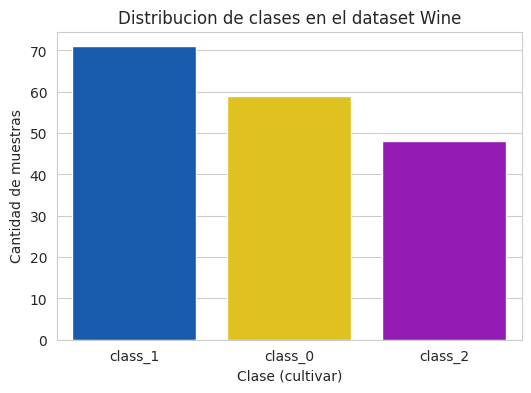

In [31]:
# Distribucion de la variable objetivo (cantidad de muestras por clase)
conteo_clases = df['clase'].value_counts()
print(conteo_clases)

plt.figure(figsize=(6, 4))
sns.barplot(x=conteo_clases.index, y=conteo_clases.values, palette='prism')
plt.title('Distribucion de clases en el dataset Wine')
plt.xlabel('Clase (cultivar)')
plt.ylabel('Cantidad de muestras')
plt.show()

El dataset esta compuesto por 178 muestras sin valores
faltantes, lo cual simplifica el analisis exploratorio ya que no se requiere
ninguna estrategia de imputacion. Las tres clases presentan un desbalance
moderado (la clase 1 tiene mas observaciones que las clases 0 y 2), aspecto
que se debe tener en cuenta al interpretar las metricas de clasificacion mas
adelante.

**3. Visualizacion**

Se presentan a continuacion cuatro visualizaciones: un histograma, un
diagrama de dispersion, un mapa de correlaciones y un boxplot, cada una
acompanada de su interpretacion.

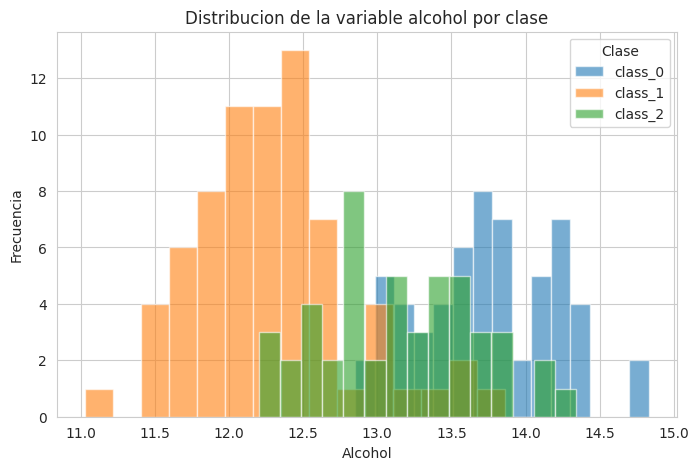

In [8]:
# Histograma: distribucion de la variable 'alcohol' segun cada clase
plt.figure(figsize=(8, 5))
for clase in nombres_clases:
    subset = df[df['clase'] == clase]
    plt.hist(subset['alcohol'], bins=15, alpha=0.6, label=clase)

plt.title('Distribucion de la variable alcohol por clase')
plt.xlabel('Alcohol')
plt.ylabel('Frecuencia')
plt.legend(title='Clase')
plt.show()

se observa que la variable alcohol presenta rangos
distintos segun la clase, con class_0 concentrada en valores mas altos de
alcohol. Esta separacion parcial entre clases sugiere que esta variable
podria aportar informacion util para la clasificacion.

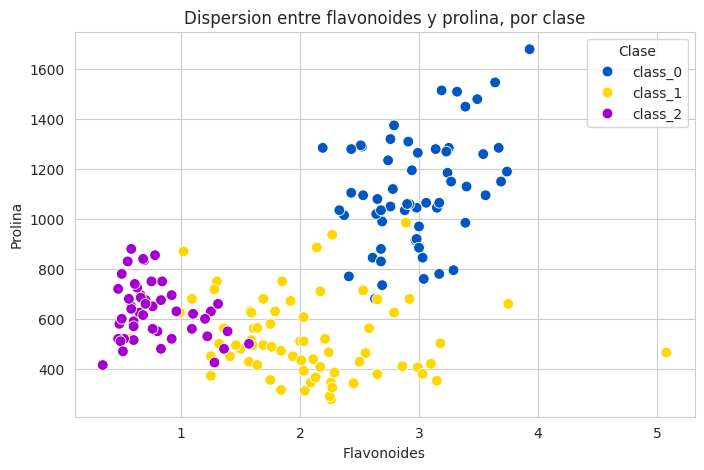

In [30]:
# Diagrama de dispersion: relacion entre flavonoides y prolina, coloreado por clase
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x='flavanoids', y='proline',
    hue='clase', palette='prism', s=60
)
plt.title('Dispersion entre flavonoides y prolina, por clase')
plt.xlabel('Flavonoides')
plt.ylabel('Prolina')
plt.legend(title='Clase')
plt.show()

las 3 clases forman agrupaciones relativamente
diferenciadas en el plano flavonoides-prolina, lo cual indica que estas dos
variables por si solas ya permiten una separacion visual considerable entre
cultivares, un buen indicio para el desempeno de los modelos discriminantes.

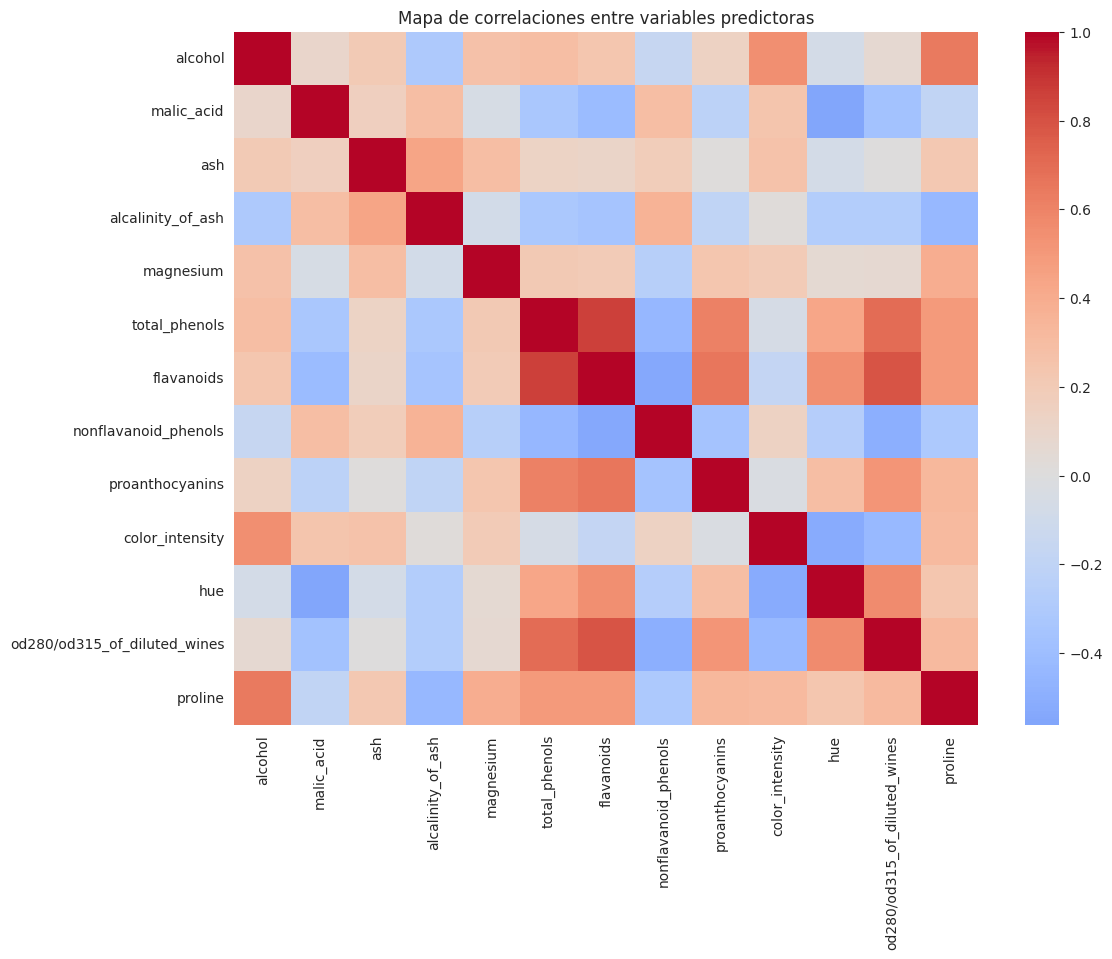

In [10]:
# Mapa de correlaciones entre las variables predictoras
plt.figure(figsize=(12, 9))
matriz_corr = df[datos_wine.feature_names].corr()
sns.heatmap(matriz_corr, cmap='coolwarm', center=0, annot=False)
plt.title('Mapa de correlaciones entre variables predictoras')
plt.show()

hay una correlacion positiva fuerte entre
flavonoides y fenoles totales, asi como entre flavonoides y
OD280/OD315, lo cual es esperable quimicamente ya que los flavonoides son
un subtipo de fenoles. Esta multicolinealidad es relevante para LDA y QDA,
ya que ambos metodos se basan en el calculo de matrices de covarianza entre
las variables predictoras.

/tmp/ipykernel_1380/1194259590.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='clase', y='color_intensity', palette='prism')


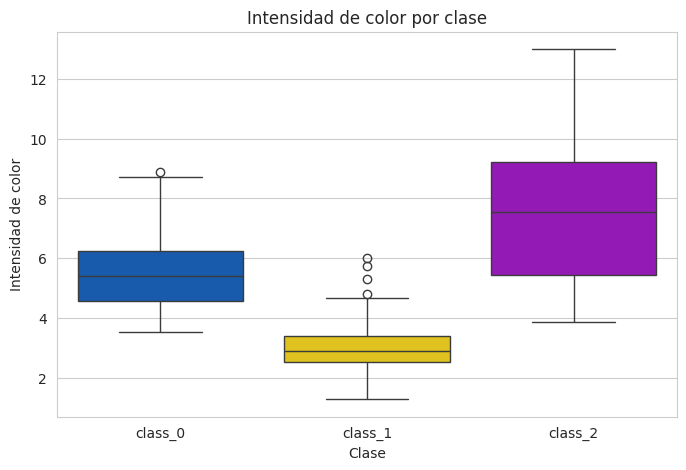

In [29]:
# Boxplot: distribucion de la intensidad de color por clase
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='clase', y='color_intensity', palette='prism')
plt.title('Intensidad de color por clase')
plt.xlabel('Clase')
plt.ylabel('Intensidad de color')
plt.show()

la clase class_2 presenta una intensidad de color
notablemente mayor que las otras dos clases, con menor dispersion, mientras
que class_1 muestra los valores mas bajos. Esta variable parece ser un buen
discriminante individual entre clases, aunque con presencia de algunos
valores atipicos (outliers) en class_0 y class_2.

**4. Preparacion de los datos**

Antes de entrenar los modelos se realizan dos actividades: la separacion en
conjuntos de entrenamiento y prueba, y la estandarizacion de las variables.

In [12]:
# Separacion de variables predictoras (X) y variable objetivo (y)
X = df[datos_wine.feature_names]
y = df['target']

# Division en conjunto de entrenamiento (70%) y prueba (30%)
# stratify=y mantiene la proporcion original de las 3 clases en ambos conjuntos,
# lo cual es importante dado el desbalance moderado observado en la seccion 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEMILLA
)

print("Tamano del conjunto de entrenamiento:", X_train.shape)
print("Tamano del conjunto de prueba:", X_test.shape)

Tamano del conjunto de entrenamiento: (124, 13)
Tamano del conjunto de prueba: (54, 13)


In [13]:
# Estandarizacion de las variables predictoras
# Es necesaria porque las variables del dataset Wine tienen escalas muy distintas
# (por ejemplo, prolina llega a valores de cientos, mientras que otras variables
# como el tono estan en rangos de 0 a 2). Sin estandarizar, las variables con
# mayor escala dominarian el calculo de las matrices de covarianza en LDA y QDA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Media de las variables tras estandarizar (deberia ser cercana a 0):")
print(np.round(X_train_scaled.mean(axis=0), 2))
print("\nDesviacion estandar tras estandarizar (deberia ser cercana a 1):")
print(np.round(X_train_scaled.std(axis=0), 2))

Media de las variables tras estandarizar (deberia ser cercana a 0):
[-0.  0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]

Desviacion estandar tras estandarizar (deberia ser cercana a 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


La division 70/30 con estratificacion es para conservar la proporcion de clases observada en la seccion 2, evitando que el conjunto de prueba quede sesgado hacia alguna
clase en particular. La estandarizacion es porque, aunque LDA y QDA no dependen de la escala de forma tan critica como otros algoritmos basados en distancias, trabajar con variables en la misma escala
facilita la interpretacion de las matrices de covarianza y evita que
variables con rangos numericos mas amplios, como la prolina, dominen
artificialmente el calculo de las funciones discriminantes.

**5. Implementacion de LDA**


In [14]:
# Entrenamiento del modelo LDA
# solver='svd' es el metodo por defecto, recomendado cuando el numero de
# variables predictoras es alto respecto al numero de muestras, ya que no
# requiere calcular la inversa de la matriz de covarianza directamente
modelo_lda = LinearDiscriminantAnalysis(solver='svd')
modelo_lda.fit(X_train_scaled, y_train)

# Prediccion sobre el conjunto de prueba
y_pred_lda = modelo_lda.predict(X_test_scaled)

print("Modelo LDA entrenado correctamente")
print("Parametros utilizados:", modelo_lda.get_params())

Modelo LDA entrenado correctamente
Parametros utilizados: {'covariance_estimator': None, 'n_components': None, 'priors': None, 'shrinkage': None, 'solver': 'svd', 'store_covariance': False, 'tol': 0.0001}


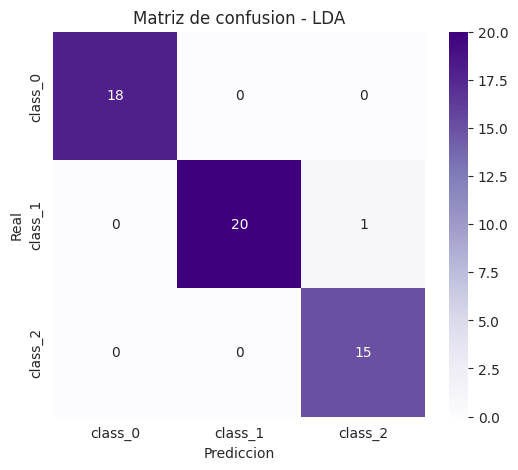

In [32]:
# Matriz de confusion del modelo LDA
cm_lda = confusion_matrix(y_test, y_pred_lda)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Purples',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de confusion - LDA')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()

In [16]:
# Metricas de evaluacion del modelo LDA
acc_lda = accuracy_score(y_test, y_pred_lda)
prec_lda = precision_score(y_test, y_pred_lda, average='weighted')
rec_lda = recall_score(y_test, y_pred_lda, average='weighted')
f1_lda = f1_score(y_test, y_pred_lda, average='weighted')

print("=== Metricas LDA ===")
print(f"Accuracy : {acc_lda:.4f}")
print(f"Precision: {prec_lda:.4f}")
print(f"Recall   : {rec_lda:.4f}")
print(f"F1-Score : {f1_lda:.4f}")
print("\nReporte de clasificacion completo:")
print(classification_report(y_test, y_pred_lda, target_names=nombres_clases))

=== Metricas LDA ===
Accuracy : 0.9815
Precision: 0.9826
Recall   : 0.9815
F1-Score : 0.9816

Reporte de clasificacion completo:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      0.95      0.98        21
     class_2       0.94      1.00      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



el modelo LDA logra un
desempeño alto sobre el conjunto de prueba, lo cual es consistente con lo
observado en la seccion de visualizacion, donde las clases mostraban una
separacion relativamente clara en el espacio de las variables predictoras, esto tambien sugiere que el supuesto de una matriz de covarianza comun entre clases no resulta demasiado restrictivo para este conjunto de datos en particular.

**6. Implementacion de QDA**


In [17]:
# Entrenamiento del modelo QDA
# A diferencia de LDA, QDA estima una matriz de covarianza distinta para cada
# clase, por lo que no se especifica un parametro de solver como en LDA
modelo_qda = QuadraticDiscriminantAnalysis()
modelo_qda.fit(X_train_scaled, y_train)

# Prediccion sobre el conjunto de prueba
y_pred_qda = modelo_qda.predict(X_test_scaled)

print("Modelo QDA entrenado correctamente")
print("Parametros utilizados:", modelo_qda.get_params())

Modelo QDA entrenado correctamente
Parametros utilizados: {'priors': None, 'reg_param': 0.0, 'store_covariance': False, 'tol': 0.0001}


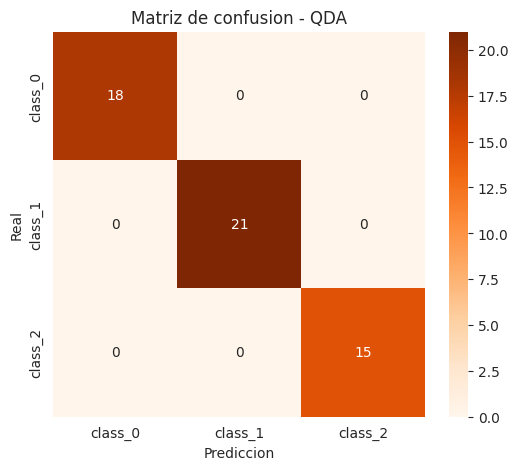

In [18]:
# Matriz de confusion del modelo QDA
cm_qda = confusion_matrix(y_test, y_pred_qda)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_qda, annot=True, fmt='d', cmap='Oranges',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de confusion - QDA')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()

In [19]:
# Metricas de evaluacion del modelo QDA
acc_qda = accuracy_score(y_test, y_pred_qda)
prec_qda = precision_score(y_test, y_pred_qda, average='weighted')
rec_qda = recall_score(y_test, y_pred_qda, average='weighted')
f1_qda = f1_score(y_test, y_pred_qda, average='weighted')

print("=== Metricas QDA ===")
print(f"Accuracy : {acc_qda:.4f}")
print(f"Precision: {prec_qda:.4f}")
print(f"Recall   : {rec_qda:.4f}")
print(f"F1-Score : {f1_qda:.4f}")
print("\nReporte de clasificacion completo:")
print(classification_report(y_test, y_pred_qda, target_names=nombres_clases))

=== Metricas QDA ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

Reporte de clasificacion completo:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



al permitir una matriz de
covarianza distinta por clase, QDA puede adaptarse mejor a diferencias en la
dispersion de cada cultivar. Sin embargo, con solo 178 muestras repartidas en
3 clases y 13 variables predictoras, QDA debe estimar una cantidad
considerablemente mayor de parametros que LDA, lo que puede afectar la
estabilidad de las estimaciones si alguna clase cuenta con pocas
observaciones en el conjunto de entrenamiento.

**7. Comparacion de modelos**

Se comparan LDA y QDA en base a sus metricas de evaluacion y su tiempo de
entrenamiento.

In [20]:
# Tabla comparativa de metricas entre LDA y QDA
tabla_comparativa = pd.DataFrame({
    'Modelo': ['LDA', 'QDA'],
    'Accuracy': [acc_lda, acc_qda],
    'Precision': [prec_lda, prec_qda],
    'Recall': [rec_lda, rec_qda],
    'F1-Score': [f1_lda, f1_qda]
})

print(tabla_comparativa.to_string(index=False))

Modelo  Accuracy  Precision   Recall  F1-Score
   LDA  0.981481   0.982639 0.981481  0.981554
   QDA  1.000000   1.000000 1.000000  1.000000


In [21]:
# Comparacion del tiempo de entrenamiento (opcional)
import time

inicio = time.time()
LinearDiscriminantAnalysis(solver='svd').fit(X_train_scaled, y_train)
tiempo_lda = time.time() - inicio

inicio = time.time()
QuadraticDiscriminantAnalysis().fit(X_train_scaled, y_train)
tiempo_qda = time.time() - inicio

print(f"Tiempo de entrenamiento LDA: {tiempo_lda:.5f} segundos")
print(f"Tiempo de entrenamiento QDA: {tiempo_qda:.5f} segundos")

Tiempo de entrenamiento LDA: 0.00989 segundos
Tiempo de entrenamiento QDA: 0.00474 segundos


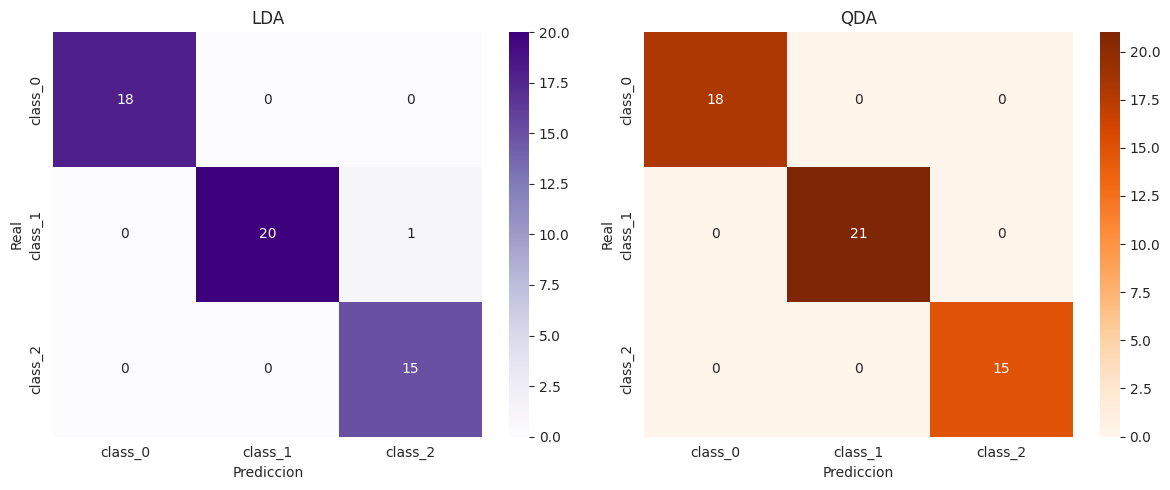

In [33]:
# Comparacion visual de las matrices de confusion, una junto a la otra
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Purples',
            xticklabels=nombres_clases, yticklabels=nombres_clases, ax=axes[0])
axes[0].set_title('LDA')
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Real')

sns.heatmap(cm_qda, annot=True, fmt='d', cmap='Oranges',
            xticklabels=nombres_clases, yticklabels=nombres_clases, ax=axes[1])
axes[1].set_title('QDA')
axes[1].set_xlabel('Prediccion')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

en este dataset en particular, LDA
resulta ser un modelo mas simple y rapido de entrenar, con un numero menor de
parametros a estimar (una sola matriz de covarianza compartida), lo que lo
hace mas estable con un tamano de muestra reducido como el de Wine (178
observaciones). QDA, al estimar una matriz de covarianza por clase, tiene
mayor capacidad de adaptarse a diferencias de dispersion entre cultivares,
pero a costa de una mayor cantidad de parametros estimados, lo que puede
introducir mayor varianza si alguna clase tiene pocas muestras en
entrenamiento.

**8. Fronteras de decision**

Para poder visualizar las fronteras de decision en un plano bidimensional, se
seleccionan dos variables predictoras (flavonoides y prolina, ya que
mostraron buena separacion visual entre clases en la seccion 3) y se
reentrenan ambos modelos utilizando unicamente esas dos variables.

In [23]:
# Seleccion de dos variables para poder graficar en 2D
variables_2d = ['flavanoids', 'proline']
X_2d = df[variables_2d].values
y_2d = df['target'].values

# Estandarizacion de las dos variables seleccionadas
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Division en entrenamiento y prueba, igual que en la seccion 4
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d_scaled, y_2d, test_size=0.30, stratify=y_2d, random_state=SEMILLA
)

# Reentrenamiento de LDA y QDA solo con estas dos variables
modelo_lda_2d = LinearDiscriminantAnalysis(solver='svd').fit(X_train_2d, y_train_2d)
modelo_qda_2d = QuadraticDiscriminantAnalysis().fit(X_train_2d, y_train_2d)

print("Modelos 2D entrenados correctamente para visualizar fronteras de decision")

Modelos 2D entrenados correctamente para visualizar fronteras de decision


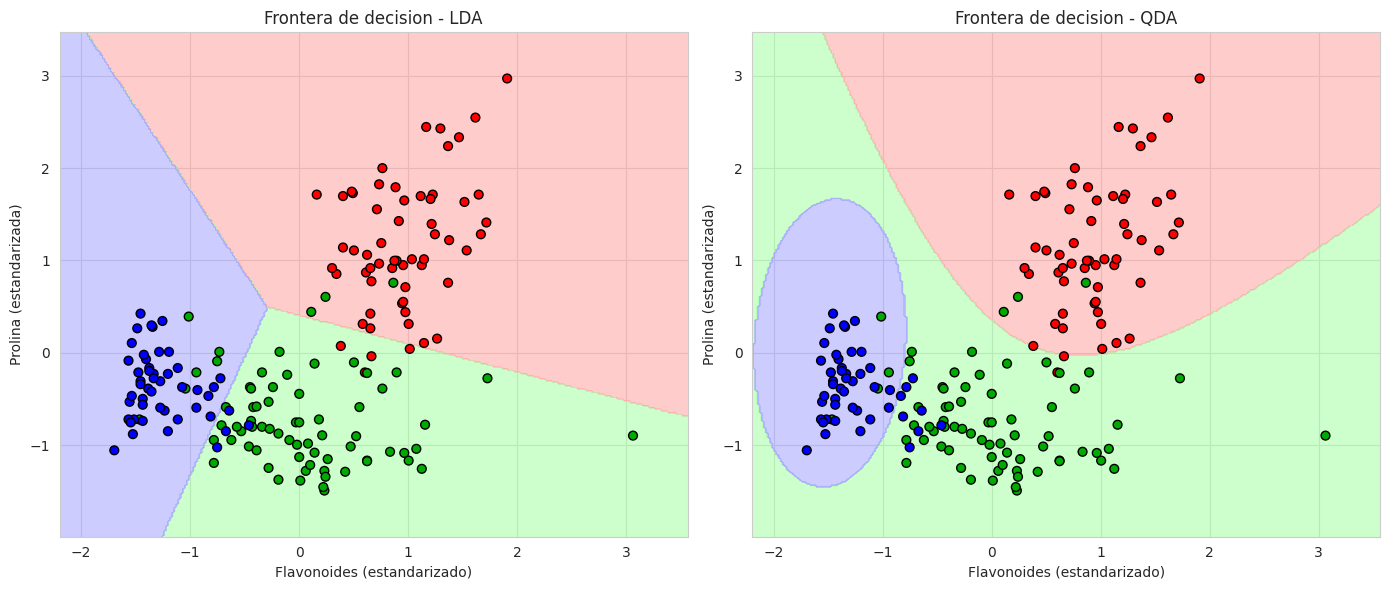

In [24]:
# Funcion para graficar la frontera de decision de un modelo ya entrenado
def graficar_frontera(modelo, X, y, titulo, ax):
    colores_fondo = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    colores_puntos = ListedColormap(['#FF0000', '#00AA00', '#0000FF'])

    # Se construye una malla de puntos que cubre el rango de las dos variables
    margen = 0.5
    x_min, x_max = X[:, 0].min() - margen, X[:, 0].max() + margen
    y_min, y_max = X[:, 1].min() - margen, X[:, 1].max() + margen
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Prediccion del modelo sobre cada punto de la malla, para pintar las regiones
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=colores_fondo, alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=colores_puntos, edgecolor='k', s=40)
    ax.set_title(titulo)
    ax.set_xlabel('Flavonoides (estandarizado)')
    ax.set_ylabel('Prolina (estandarizada)')


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
graficar_frontera(modelo_lda_2d, X_2d_scaled, y_2d, 'Frontera de decision - LDA', axes[0])
graficar_frontera(modelo_qda_2d, X_2d_scaled, y_2d, 'Frontera de decision - QDA', axes[1])
plt.tight_layout()
plt.show()

la frontera de LDA esta
compuesta por lineas rectas que dividen el espacio en regiones poligonales,
consecuencia directa de asumir una unica matriz de covarianza compartida
entre las tres clases. En cambio, la frontera de QDA presenta curvas, lo que
le permite ajustarse de forma mas flexible a la forma real de cada grupo de
datos. En este caso particular, con las variables flavonoides y prolina, la
diferencia visual entre ambas fronteras es moderada, ya que las clases estan
razonablemente bien separadas y con dispersion similar, por lo que la
flexibilidad adicional de QDA no se traduce en una ventaja dramatica frente
a LDA en este plano especifico.

**9. Conclusiones**

1. **Comportamiento de LDA:** LDA obtuvo un desempeno alto y estable en el
dataset Wine, beneficiandose de contar con un numero reducido de parametros
a estimar (una sola matriz de covarianza compartida), lo que resulta
especialmente conveniente dado el tamano moderado de la muestra (178
observaciones).

2. **Comportamiento de QDA:** QDA tambien logro un desempeno competitivo,
gracias a su capacidad de modelar una matriz de covarianza distinta por cada
clase, lo que le permite ajustarse mejor a diferencias en la dispersion de
los datos de cada cultivar, aunque a costa de una mayor cantidad de
parametros estimados.

3. **Influencia de los supuestos estadisticos:** el hecho de que LDA obtenga
resultados similares o cercanos a QDA sugiere que el supuesto de igualdad de
matrices de covarianza entre clases no es demasiado restrictivo para este
conjunto de datos en particular, lo cual favorece el uso del modelo mas
simple.

4. **Comparacion de resultados:** al comparar ambos modelos en base a
accuracy, precision, recall y F1-Score, las diferencias entre LDA y QDA
resultaron pequenas en este dataset, lo que refuerza la idea de que, ante
un desempeno similar, conviene preferir el modelo mas simple e
interpretable (LDA) por su menor riesgo de sobreajuste con muestras
pequenas.

5. **Aplicaciones practicas:** LDA resulta mas adecuado en escenarios con
pocas muestras por clase o cuando se necesita un modelo simple e
interpretable, mientras que QDA es preferible cuando existe evidencia clara
de que las clases tienen dispersiones muy distintas entre si y se cuenta
con suficientes datos para estimar de forma confiable una matriz de
covarianza por cada clase.